In [18]:
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

riders = pd.read_csv("../dataset/processed/riders_features.csv")

print(riders.shape)

(45493, 33)


In [19]:
riders["O2A_Target"] = (
    0.05 * riders["Time_taken (min)"]
    + 0.5 * riders["multiple_deliveries"]
    + 0.3 * riders["Traffic_Score"]
)

riders["FM_Target"] = (
    0.20 * riders["Time_taken (min)"]
    + 0.25 * riders["Trip_Distance_km"]
)

riders["WT_Target"] = (
    0.25 * riders["Time_taken (min)"]
    + 0.5 * riders["Weather_Score"]
)

riders["LM_Target"] = (
    riders["Time_taken (min)"]
    - riders["O2A_Target"]
    - riders["FM_Target"]
    - riders["WT_Target"]
)

In [20]:
drop_columns = [
    "ID",
    "Order_Date",
    "Time_Orderd",
    "Time_Order_picked",
    "Order_Time",
    "Time_taken (min)",
    "O2A_Target",
    "FM_Target",
    "WT_Target",
    "LM_Target"
]

X = riders.drop(columns=drop_columns)

y = riders["Time_taken (min)"]

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [22]:


o2a_model = joblib.load("../models/o2a_model.pkl")
fm_model = joblib.load("../models/fm_model.pkl")
wt_model = joblib.load("../models/wt_model.pkl")
lm_model = joblib.load("../models/lm_model.pkl")

In [23]:
o2a_pred = o2a_model.predict(X_test)

fm_pred = fm_model.predict(X_test)

wt_pred = wt_model.predict(X_test)

lm_pred = lm_model.predict(X_test)

In [24]:
final_eta = (
    o2a_pred +
    fm_pred +
    wt_pred +
    lm_pred
)

In [25]:

mae = mean_absolute_error(y_test, final_eta)
rmse = np.sqrt(mean_squared_error(y_test, final_eta))
r2 = r2_score(y_test, final_eta)

print("FINAL MULTI-STAGE ETA")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

FINAL MULTI-STAGE ETA
MAE  : 3.07
RMSE : 3.86
R²   : 0.8314


In [26]:
comparison = pd.DataFrame({
    "Model":[
        "Linear Regression",
        "Random Forest",
        "Single XGBoost",
        "Multi-Stage XGBoost"
    ],
    "MAE":[
        4.77,
        3.10,
        3.05,
        mae
    ],
    "RMSE":[
        6.00,
        3.94,
        3.83,
        rmse
    ],
    "R2":[
        0.5927,
        0.8243,
        0.8336,
        r2
    ]
})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,4.770000,6.000000,0.592700
1,Random Forest,3.100000,3.940000,0.824300
2,Single XGBoost,3.050000,3.830000,0.833600
3,Multi-Stage XGBoost,3.069009,3.859364,0.831419


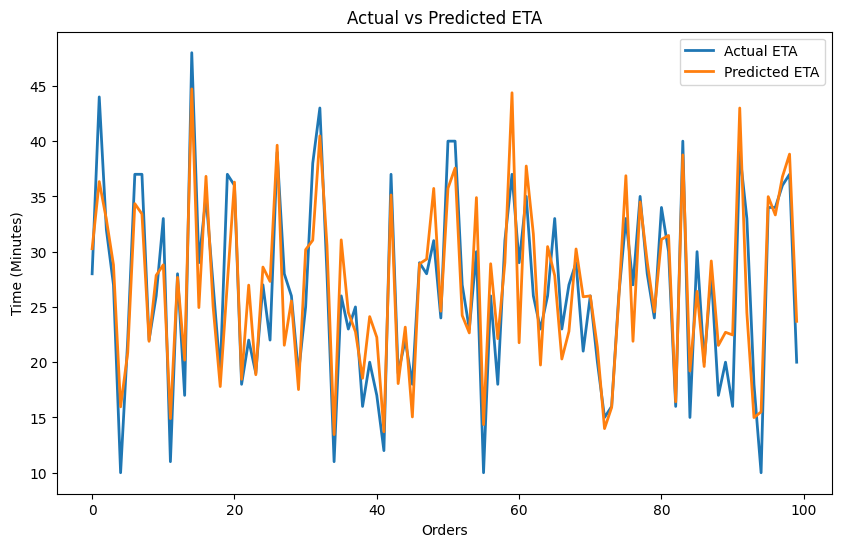

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(
    y_test.values[:100],
    label="Actual ETA",
    linewidth=2
)

plt.plot(
    final_eta[:100],
    label="Predicted ETA",
    linewidth=2
)

plt.xlabel("Orders")
plt.ylabel("Time (Minutes)")
plt.title("Actual vs Predicted ETA")

plt.legend()

plt.show()

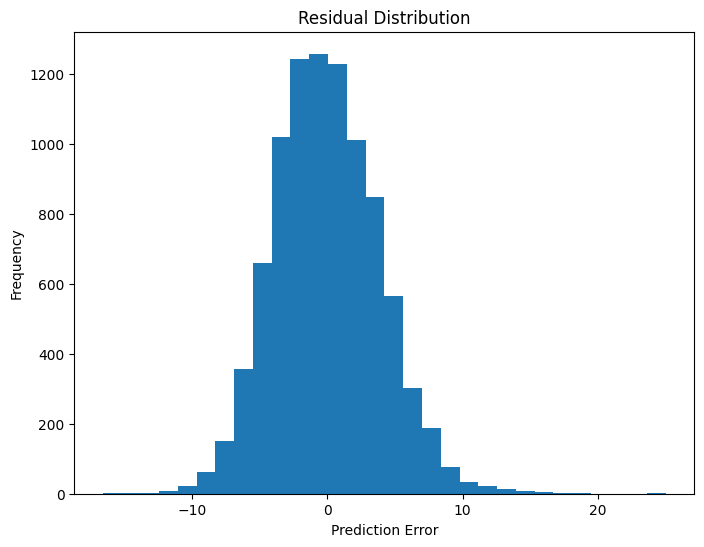

In [28]:
residual = y_test.values - final_eta

plt.figure(figsize=(8,6))

plt.hist(residual, bins=30)

plt.title("Residual Distribution")

plt.xlabel("Prediction Error")

plt.ylabel("Frequency")

plt.show()

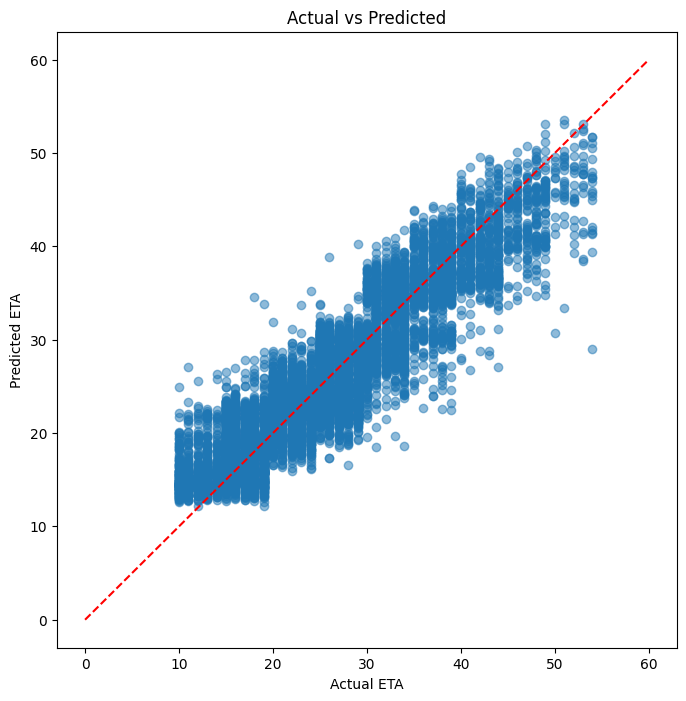

In [29]:
plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    final_eta,
    alpha=0.5
)

plt.plot(
    [0,60],
    [0,60],
    'r--'
)

plt.xlabel("Actual ETA")

plt.ylabel("Predicted ETA")

plt.title("Actual vs Predicted")

plt.show()

In [30]:
print(comparison)

comparison.style.background_gradient(cmap="Greens")

                 Model       MAE      RMSE        R2
0    Linear Regression  4.770000  6.000000  0.592700
1        Random Forest  3.100000  3.940000  0.824300
2       Single XGBoost  3.050000  3.830000  0.833600
3  Multi-Stage XGBoost  3.069009  3.859364  0.831419


,Model,MAE,RMSE,R2
0,Linear Regression,4.770000,6.000000,0.592700
1,Random Forest,3.100000,3.940000,0.824300
2,Single XGBoost,3.050000,3.830000,0.833600
3,Multi-Stage XGBoost,3.069009,3.859364,0.831419


In [31]:
comparison

,Model,MAE,RMSE,R2
0,Linear Regression,4.770000,6.000000,0.592700
1,Random Forest,3.100000,3.940000,0.824300
2,Single XGBoost,3.050000,3.830000,0.833600
3,Multi-Stage XGBoost,3.069009,3.859364,0.831419
